<a href="https://colab.research.google.com/github/LaisST/FIAP_202501_HandsOn_data_analytics/blob/main/Fase_5/Fase5_Perceptron_de_multiplas_camadas_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 5 - Aula 1
## Perceptron de múltiplas camadas

## Classificando diferentes tipos de semente de abóbora

In [26]:
# Importar as bibliotecas
# Tratativa dos dados
import pandas as pd

# Embaralhar a base
from sklearn.utils import shuffle

# Visualização
import seaborn as sns
import matplotlib.pyplot as plt

# Codificar colunas do tipo texto utilizadno Label Enconder
from sklearn.preprocessing import LabelEncoder

# Separação da base (Treino e Teste)
from sklearn.model_selection import train_test_split

# Normalizar e Padronizar a base
from sklearn.preprocessing import StandardScaler

In [3]:
# Importar base
df = pd.read_excel("/content/SementesAbobora.xlsx")
df.head()

,Area,Perímetro,Maior_Eixo_Comprimento,Comprimento_Eixo_Menor,Área_Convexa,Equiv_Diâmetro,Excentricidade,Solidez,Extensão,Redondeza,Proporcao,Compacidade,Class
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,(A) Çerçevelik
1,76631,1068.146,417.1932,234.2289,77280,312.3614,0.8275,0.9916,0.7151,0.8440,1.7811,0.7487,(A) Çerçevelik
2,71623,1082.987,435.8328,211.0457,72663,301.9822,0.8749,0.9857,0.7400,0.7674,2.0651,0.6929,(A) Çerçevelik
3,66458,992.051,381.5638,222.5322,67118,290.8899,0.8123,0.9902,0.7396,0.8486,1.7146,0.7624,(A) Çerçevelik
4,66107,998.146,383.8883,220.4545,67117,290.1207,0.8187,0.9850,0.6752,0.8338,1.7413,0.7557,(A) Çerçevelik


In [7]:
# Analisar as dimensões da base
print(f"Linhas: {df.shape[0]}. Colunas: {df.shape[1]}")


Linhas: 2500. Colunas: 13


In [18]:
# Tipos de Dados
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2500 entries, 484 to 1224
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area                    2500 non-null   int64  
 1   Perímetro               2500 non-null   float64
 2   Maior_Eixo_Comprimento  2500 non-null   float64
 3   Comprimento_Eixo_Menor  2500 non-null   float64
 4   Área_Convexa            2500 non-null   int64  
 5   Equiv_Diâmetro          2500 non-null   float64
 6   Excentricidade          2500 non-null   float64
 7   Solidez                 2500 non-null   float64
 8   Extensão                2500 non-null   float64
 9   Redondeza               2500 non-null   float64
 10  Proporcao               2500 non-null   float64
 11  Compacidade             2500 non-null   float64
 12  Class                   2500 non-null   object 
dtypes: float64(10), int64(2), object(1)
memory usage: 273.4+ KB


Como a base está ordenada, é importante embaralhar a base de dados para não interferir no aprendizado do modelo.

In [9]:
# Usar a biblioteca shuffle
df = shuffle(df)
df.head()

,Area,Perímetro,Maior_Eixo_Comprimento,Comprimento_Eixo_Menor,Área_Convexa,Equiv_Diâmetro,Excentricidade,Solidez,Extensão,Redondeza,Proporcao,Compacidade,Class
484,65594,1017.748,408.5607,205.4268,66341,288.9929,0.8644,0.9887,0.6633,0.7958,1.9888,0.7073,(A) Çerçevelik
789,77047,1081.920,419.2447,234.8384,77801,313.2081,0.8284,0.9903,0.7250,0.8271,1.7852,0.7471,(A) Çerçevelik
461,64691,994.607,388.4194,213.5622,65473,286.9968,0.8353,0.9881,0.6945,0.8218,1.8188,0.7389,(A) Çerçevelik
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,(A) Çerçevelik
1723,71563,1099.323,470.8907,194.1545,72156,301.8557,0.9110,0.9918,0.6749,0.7441,2.4253,0.6410,(B) Ürgüp Sivrisi


Entender o equilibrio da base

In [11]:
# Avaliar a quantidade de linhas de cada classe (target) para validar se está equilibrada
df['Class'].value_counts()

,count
Class,
(A) Çerçevelik,1300
(B) Ürgüp Sivrisi,1200


### Analise Exploratória

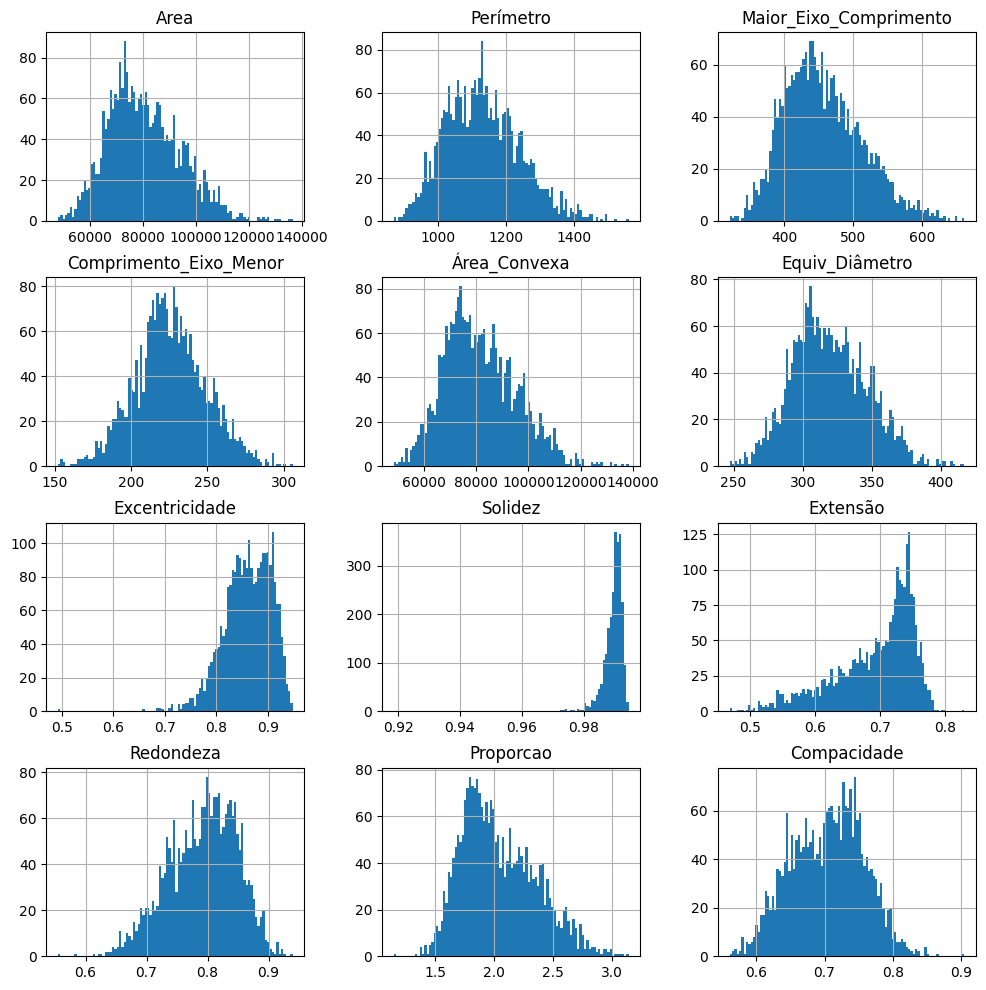

In [13]:
#Plotar histogramas para analisar a simetria dos dados
df.hist(bins=100, figsize=(12, 12))
plt.show()

Podemos observar que existem muitas variáveis com a distribuição quase que normal, ou seja, não temos muitos outliers exeto para as variáveis: Proporcao, Redondeza e Compacidade que possuem distribuição assimétrica muito forte.

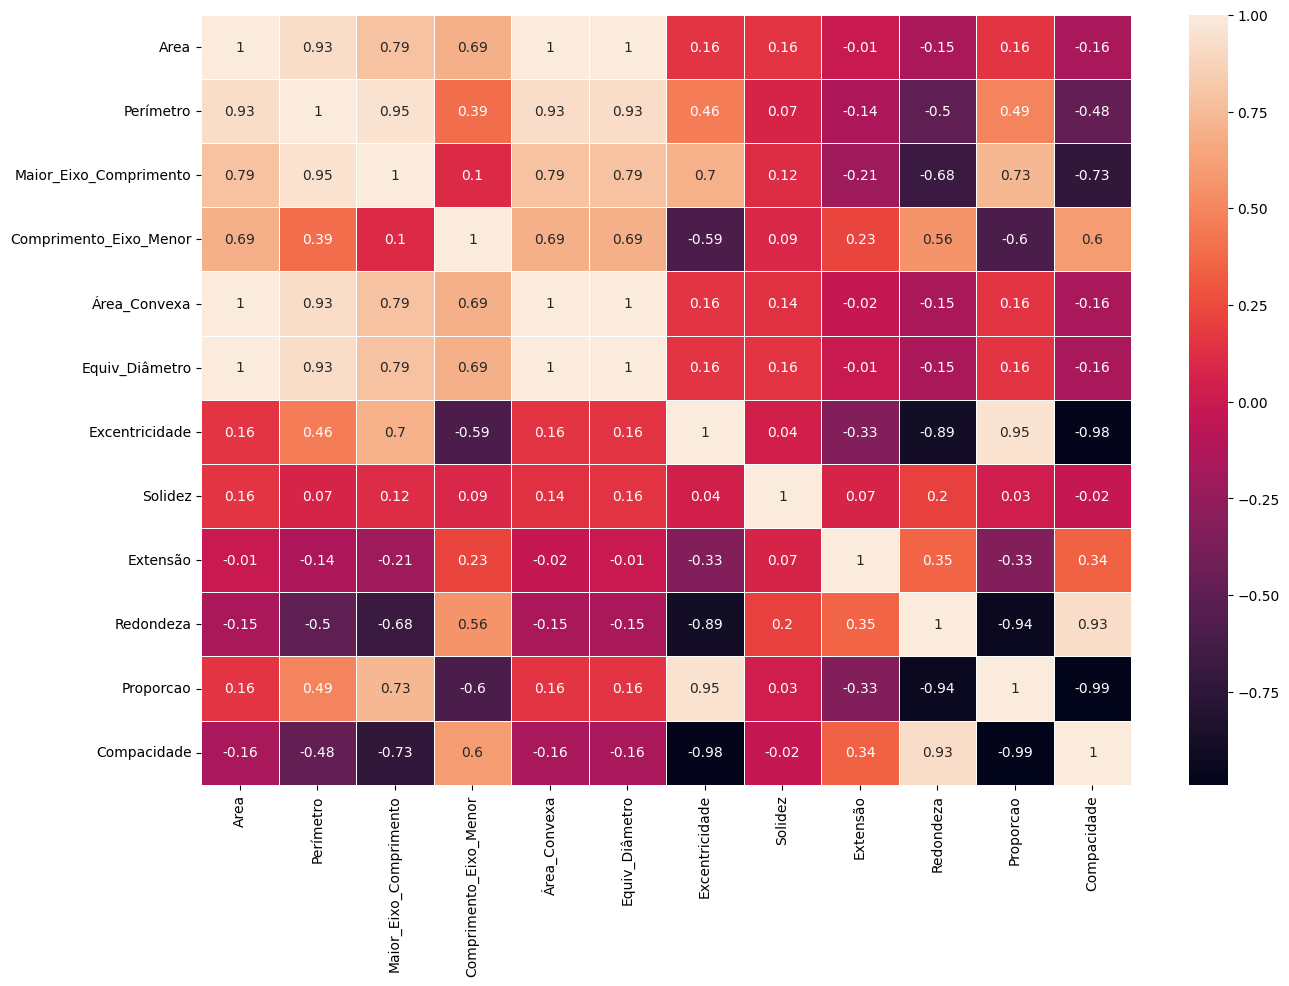

In [16]:
# Correlação das colunas
correlation_matrix = df.corr(numeric_only=True).round(2)

fig, ax = plt.subplots(figsize=(15,10))
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax)
plt.show()

A correlação é muito importante para entendermos as relações das variáveis (ou seja, a associação entre duas variáveis). Podemos identificar aqui que temos variáveis altamente correlacionadas e sabemos que isso pode ser um problema para o modelo.

Area, Area_convexa, Equiv_Diâmetro e Maior_Eixo_Comprimento possuem correlação maior que 0.90 quando analisadas com a variável Perímetro, isso se deve pelo motivo que que todas essas variáveis são relacionadas ao tamanho das sementes. Já sabemos que não precisamos colocar todas no modelo.

### Tratar a Variavel Target

In [19]:
# Transformar a coluna string para number
le = LabelEncoder()
df.Class = le.fit_transform(df['Class'])
df.head()

,Area,Perímetro,Maior_Eixo_Comprimento,Comprimento_Eixo_Menor,Área_Convexa,Equiv_Diâmetro,Excentricidade,Solidez,Extensão,Redondeza,Proporcao,Compacidade,Class
484,65594,1017.748,408.5607,205.4268,66341,288.9929,0.8644,0.9887,0.6633,0.7958,1.9888,0.7073,0
789,77047,1081.920,419.2447,234.8384,77801,313.2081,0.8284,0.9903,0.7250,0.8271,1.7852,0.7471,0
461,64691,994.607,388.4194,213.5622,65473,286.9968,0.8353,0.9881,0.6945,0.8218,1.8188,0.7389,0
0,56276,888.242,326.1485,220.2388,56831,267.6805,0.7376,0.9902,0.7453,0.8963,1.4809,0.8207,0
1723,71563,1099.323,470.8907,194.1545,72156,301.8557,0.9110,0.9918,0.6749,0.7441,2.4253,0.6410,1


In [20]:
# Valores da coluna Class (virou binário)
set(df['Class'])

{0, 1}

### Separando os dados


In [22]:
# Conferir o tipo de dado
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2500 entries, 484 to 1224
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area                    2500 non-null   int64  
 1   Perímetro               2500 non-null   float64
 2   Maior_Eixo_Comprimento  2500 non-null   float64
 3   Comprimento_Eixo_Menor  2500 non-null   float64
 4   Área_Convexa            2500 non-null   int64  
 5   Equiv_Diâmetro          2500 non-null   float64
 6   Excentricidade          2500 non-null   float64
 7   Solidez                 2500 non-null   float64
 8   Extensão                2500 non-null   float64
 9   Redondeza               2500 non-null   float64
 10  Proporcao               2500 non-null   float64
 11  Compacidade             2500 non-null   float64
 12  Class                   2500 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 273.4 KB


In [23]:
# Definir as features e target
X = df[['Area','Perímetro', 'Comprimento_Eixo_Menor','Excentricidade','Solidez','Extensão','Redondeza', 'Proporcao', 'Compacidade']]
y = df['Class']

In [25]:
# Dividir a base em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

### Pré-processamento dos dados

Apesar de deep learning não requerer distribuições normais, é comum aplicar técnicas de pré-processamento de dados para normalizar ou padronizar as características. Isso pode ajudar a acelerar a convergência do treinamento da rede neural.

A convergência está relacionada com o erro, ou seja, o quanto a sua rede aprende a corrigir os erros durante o processamento.

In [27]:
# Padronizar/Escalonamento das features
scaler = StandardScaler()
scaler.fit(X_train)
scaler.fit(X_test)

StandardScaler()

In [28]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
# Conferindo a quantidade das bases Treino e Teste
print(f"Linhas de Treino: {X_train.shape[0]} | Colunas: {X_train.shape[1]}")
print(f"Linhas Teste: {X_test.shape[0]} | Colunas: {X_test.shape[1]}")

Linhas de Treino: 2000 | Colunas: 9
Linhas Teste: 500 | Colunas: 9
